In [ ]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.model_selection import TimeSeriesSplit


pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);
#=========================
#=====================
#=========mlflow setting==========


#mlflow.set_tracking_uri(
#    "http://127.0.0.1:5000"
#)


#mlflow.set_experiment('isCnan_mhd')
#=============== feature engineering and define the needed features

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

df[((df['CH4_flag_ht']=='B')|(df['CH4_flag_a']=='B'))]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777226 entries, 1994-02-16 14:29:00 to 2025-12-31 23:58:00
Data columns (total 71 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    777226 non-null  int64  
 1   time                    777226 non-null  int64  
 2   type                    777226 non-null  object 
 3   sample                  777226 non-null  object 
 4   standard                777226 non-null  object 
 5   port                    777226 non-null  int64  
 6   ht                      777226 non-null  float64
 7   tmod                    672468 non-null  float64
 8   tamb                    672468 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   775251 non-null  float64
 11  psamp                   775257 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    775198 non-null  float64

In [4]:
df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

#  Label1


#=====================ml PART

In [5]:
target ='label1'

In [6]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [7]:
from pulearn import ElkanotoPuClassifier
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.fit_transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()


['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [8]:
X_train_final, X_test_final = (X_train_final.drop(columns='type'), 
                               X_test_final.drop(columns='type'))

#selected_features = slected_col(X_train_final)
#X_train_final  = X_train_final [feature_ml]


#X_test_final  = X_test_final [feature_ml]


In [16]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier


n_bags = 5

# obtain positive and unlabled index
pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

# obtain the number of positive and unlabeled data
number_pos = len(pos_idx)
print("Positive:", len(pos_idx))
print("Unlabeled:", len(unl_idx))

rng = np.random.default_rng(42)

feature_importances = []
models = []

for bag in range(n_bags):
    sampled_pos = pos_idx

    #select same number data of positive data from unlabeld data
    sampled_unl_idx = rng.choice(
        unl_idx,
        size=number_pos,
        replace=False
    )

    sampled_idx = np.concatenate([
        pos_idx,
        sampled_unl_idx
    ])


    rng.shuffle(sampled_idx)

    X_pu = X_train_final.iloc[sampled_idx]
    y_pu = y_train.iloc[sampled_idx]

    print(
        f"\n PU training data, Bag {bag +1}/{n_bags}"
        f"Positive = {(y_pu ==1).sum()}, "
        f"Unlabeled = {(y_pu == 0).sum()}"
    )

    base_rf = RandomForestClassifier(
        random_state=42
    )

    base_rf.fit(X_pu, y_pu)

    models.append(base_rf)

    feature_importances.append(
        base_rf.feature_importances_
    )


Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5Positive = 21442, Unlabeled = 21442


In [21]:
importance_df = pd.DataFrame(
    feature_importances,
    columns=X_train_final.columns
)
importance_summary = pd.DataFrame({
    "Feature": X_train_final.columns,
    "importance_mean":importance_df.mean(axis=0),
    "importance_std": importance_df.std(axis=0),
    "importance_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
}).sort_values(
    "importance_mean", ascending=False
    )


importance_summary

,Feature,importance_mean,importance_std,importance_cv percent
CH4_rt_to_last_air_ratio,CH4_rt_to_last_air_ratio,0.029920,0.001665,5.564666
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,0.027924,0.000879,3.147626
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,CH4_area_roll_std_24h_CH4_area_roll_mean_24h_r...,0.024398,0.001848,7.574226
CH4_end_time,CH4_end_time,0.020413,0.000868,4.254322
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,0.018554,0.001313,7.075909
CH4_ht_to_last_std_ratio,CH4_ht_to_last_std_ratio,0.018509,0.000283,1.527260
CH4_w_residual_3h,CH4_w_residual_3h,0.018254,0.007399,40.536725
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,0.018031,0.000753,4.176087
CH4_w_residual_6h,CH4_w_residual_6h,0.016848,0.001448,8.593737
CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio,CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio,0.016649,0.000463,2.783804


if mean is high but cv is high also,
that means the importance of feature relys on what kind of sample selected
for example: CH4_w_residual_3h :top 7,  cv is 40.536725 -> importance highly relates to the data selected (may not be so stable)

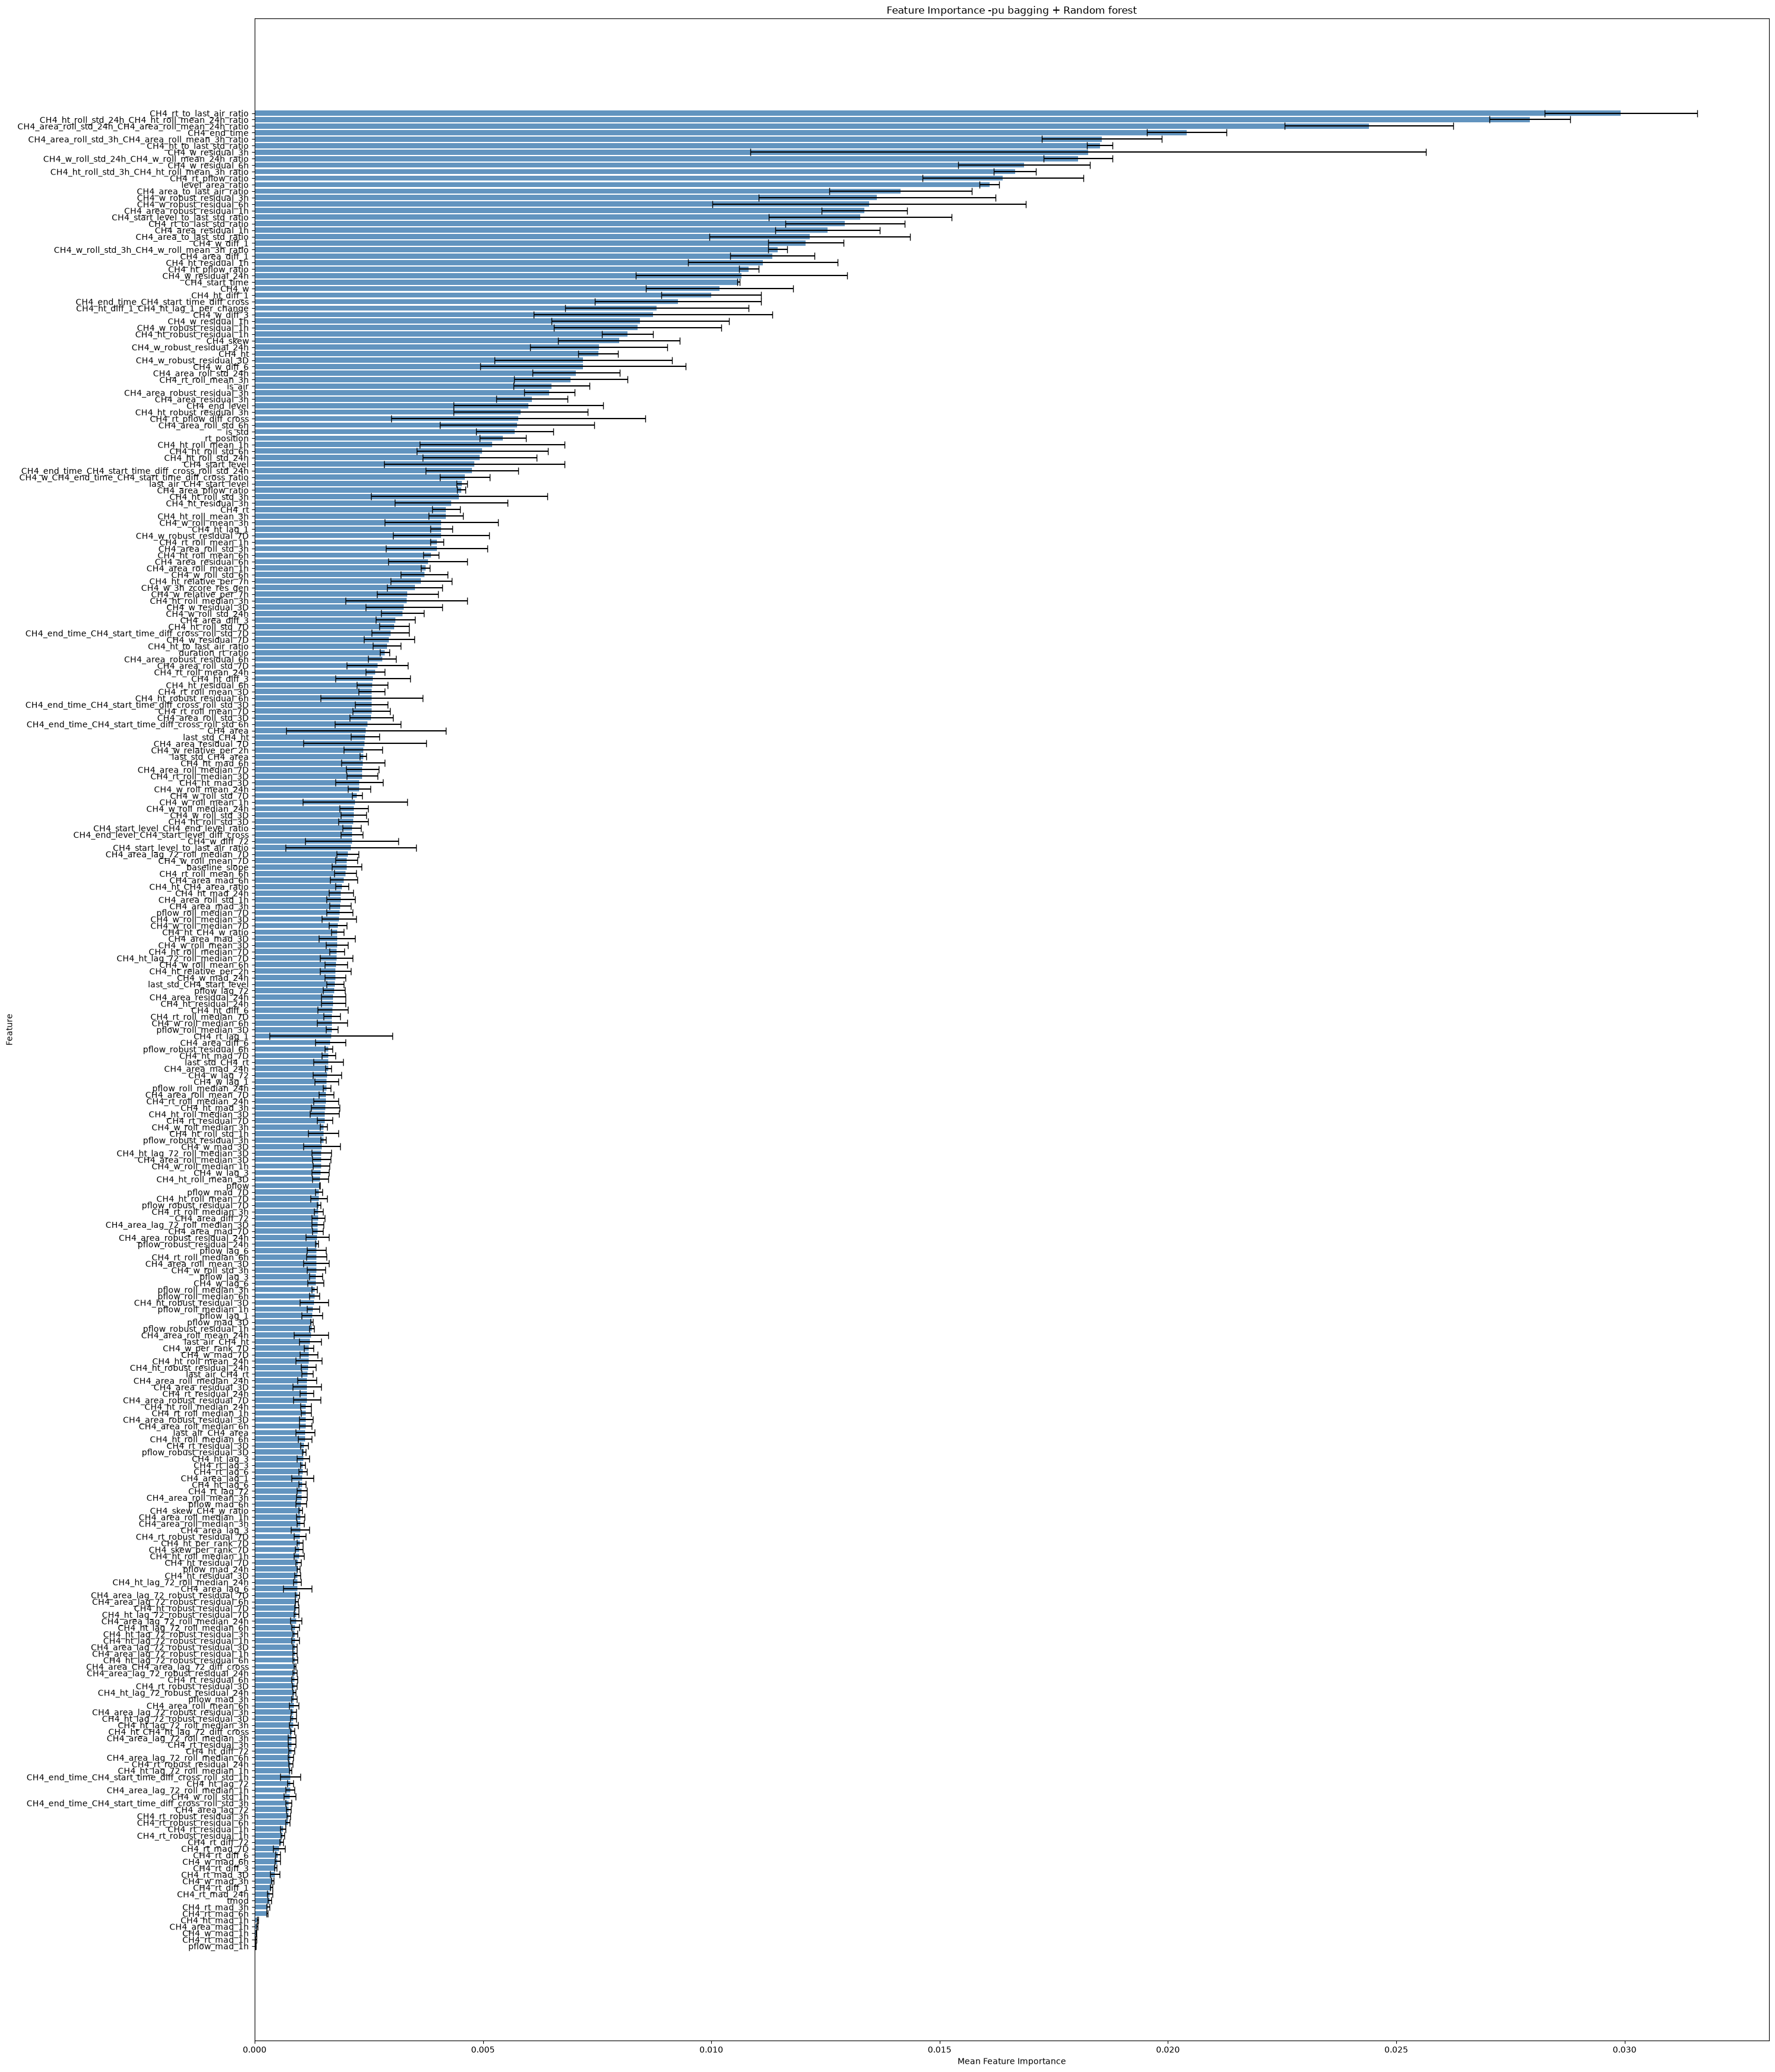

In [26]:
plot_df = (
    importance_summary.sort_values("importance_mean")
)
plt.figure(figsize=(30,35))

plt.barh(
    plot_df['Feature'],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=4,
    color="steelblue",
    alpha=0.85
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance -pu bagging + Random forest")
plt.tight_layout()
plt.show()

In [36]:
def bagging_rf(n_bags, X_train_final, y_train):
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    feature_importances = []
    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])


        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )

        base_rf = RandomForestClassifier(
            random_state=42
        )

        base_rf.fit(X_pu, y_pu)

        models.append(base_rf)

        feature_importances.append(
            base_rf.feature_importances_
        )

    importance_df = pd.DataFrame(
        feature_importances,
        columns=X_train_final.columns
    )
    importance_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
        "importance_mean":importance_df.mean(axis=0),
        "importance_std": importance_df.std(axis=0),
        "importance_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
    }).sort_values(
        "importance_mean", ascending=False
        )

    rank_df = importance_df.rank(
        axis=1,
        ascending=False,
        method="average"
    ) # rank in every bag iter

    rank_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
            "rank_mean":rank_df.mean(axis=0),
            "rank_std": importance_df.std(axis=0),
            "rank_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
        }).sort_values(
            "rank_mean"
            )
    return models, importance_summary, rank_summary
    


#### Bagging for 20 bags

In [37]:
models_5, importance_summary_5, rank_5 = bagging_rf(5, X_train_final, y_train)
models_10, importance_summary_10, rank_10 = bagging_rf(10, X_train_final, y_train)
models_15, importance_summary_15, rank_15 = bagging_rf(15, X_train_final, y_train)
models_30, importance_summary_30, rank_30 = bagging_rf(30, X_train_final, y_train)

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

87 mins

=====

In [38]:
importance_summary_5.to_csv("csv/importance_summary_5.csv", index=False)
importance_summary_10.to_csv("csv/importance_summary_10.csv", index=False)
importance_summary_15.to_csv("csv/importance_summary_15.csv", index=False)
importance_summary_30.to_csv("csv/importance_summary_30.csv", index=False)


rank_5.to_csv("csv/rank_5.csv", index=False)
rank_10.to_csv("csv/rank_10.csv", index=False)
rank_15.to_csv("csv/rank_15.csv", index=False)
rank_30.to_csv("csv/rank_30.csv", index=False)

### Visulize feature importance

In [42]:
importance_compare = pd.concat({
    "5 bag": importance_summary_5.set_index("Feature")["importance_mean"],
    "10 bag": importance_summary_10.set_index("Feature")["importance_mean"],
    "15 bag": importance_summary_15.set_index("Feature")["importance_mean"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_mean"]
}, axis = 1)

importance_compare 

,5 bag,10 bag,15 bag,30 bag
Feature,,,,
CH4_rt_to_last_air_ratio,0.029920,0.030827,0.030924,0.031198
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,0.027924,0.028317,0.028466,0.028629
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,0.024398,0.024290,0.024439,0.024560
CH4_end_time,0.020413,0.020577,0.020525,0.020540
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,0.018554,0.018354,0.018415,0.018389
CH4_ht_to_last_std_ratio,0.018509,0.018525,0.018570,0.018589
CH4_w_residual_3h,0.018254,0.016441,0.015617,0.014746
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,0.018031,0.019056,0.018648,0.018939
CH4_w_residual_6h,0.016848,0.017957,0.018648,0.017809


28 above 0.001

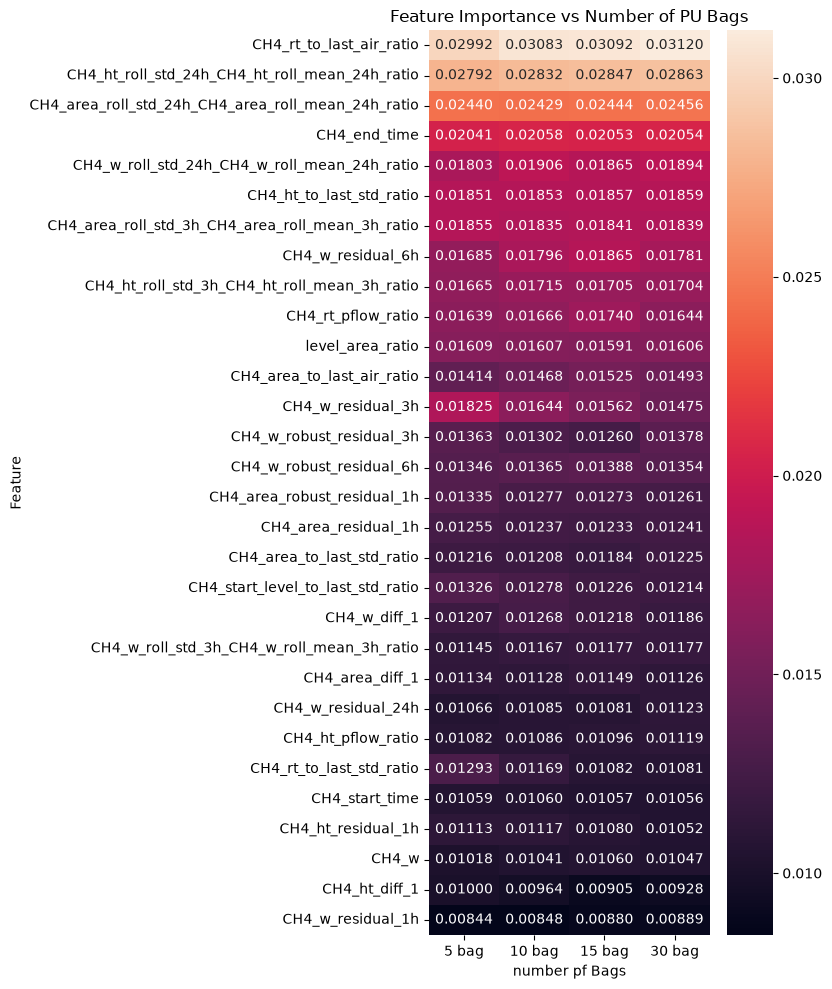

<Figure size 640x480 with 0 Axes>

In [52]:
top30 = importance_summary_30.head(30)["Feature"]
plot_data = importance_compare.loc[top30]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".5f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp5_30_compare.png")

### CV performance

In [50]:
cv_compare = pd.concat({
    "5 bag": importance_summary_5.set_index("Feature")["importance_cv percent"],
    "10 bag": importance_summary_10.set_index("Feature")["importance_cv percent"],
    "15 bag": importance_summary_15.set_index("Feature")["importance_cv percent"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_cv percent"]
}, axis = 1)

cv_compare

,5 bag,10 bag,15 bag,30 bag
Feature,,,,
CH4_rt_to_last_air_ratio,5.564666,4.760354,4.531673,3.673206
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,3.147626,7.166206,6.486315,5.519080
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,7.574226,7.263973,7.007361,6.734668
CH4_end_time,4.254322,3.967305,3.464133,2.815114
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,7.075909,6.965283,5.901222,5.687151
CH4_ht_to_last_std_ratio,1.527260,2.332182,2.737127,2.996742
CH4_w_residual_3h,40.536725,32.945120,29.436331,27.368714
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,4.176087,10.762595,9.708760,9.148216
CH4_w_residual_6h,8.593737,21.026524,25.381847,22.781051


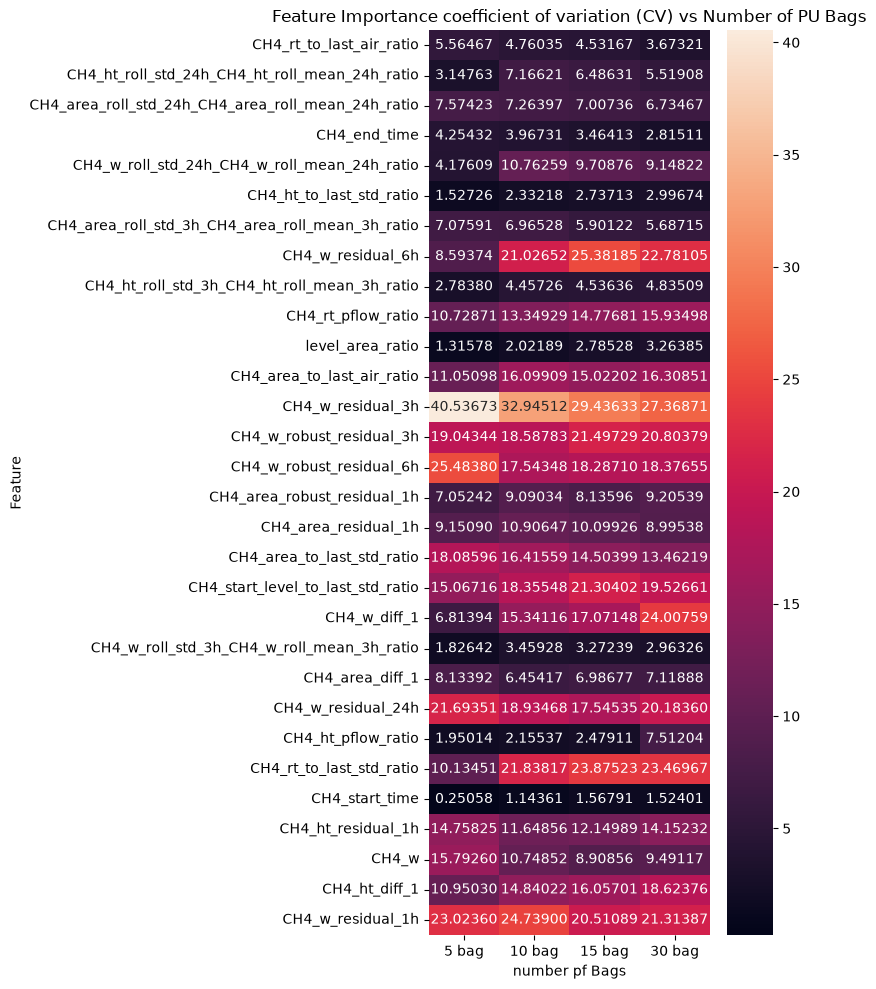

<Figure size 640x480 with 0 Axes>

In [61]:

plot_data = cv_compare.loc[top30]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".5f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance coefficient of variation (CV) vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp5_30__cv_compare.png")

### Rank Compare

In [55]:
rank_compare = pd.concat({
    "5 bag": rank_5.set_index("Feature")["rank_mean"],
    "10 bag": rank_10.set_index("Feature")["rank_mean"],
    "15 bag": rank_15.set_index("Feature")["rank_mean"],
    "30 bag": rank_30.set_index("Feature")["rank_mean"]
}, axis = 1)

rank_compare

,5 bag,10 bag,15 bag,30 bag
Feature,,,,
CH4_rt_to_last_air_ratio,1.2,1.2,1.200000,1.133333
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,1.8,1.9,2.000000,2.000000
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,3.2,3.2,3.200000,3.066667
CH4_end_time,4.4,4.6,4.800000,4.566667
CH4_ht_to_last_std_ratio,6.2,6.5,6.600000,6.700000
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,7.2,7.2,7.266667,7.133333
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,7.8,7.0,7.600000,7.133333
CH4_w_residual_6h,9.8,9.1,8.666667,9.500000
CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio,10.0,9.4,9.600000,9.566667


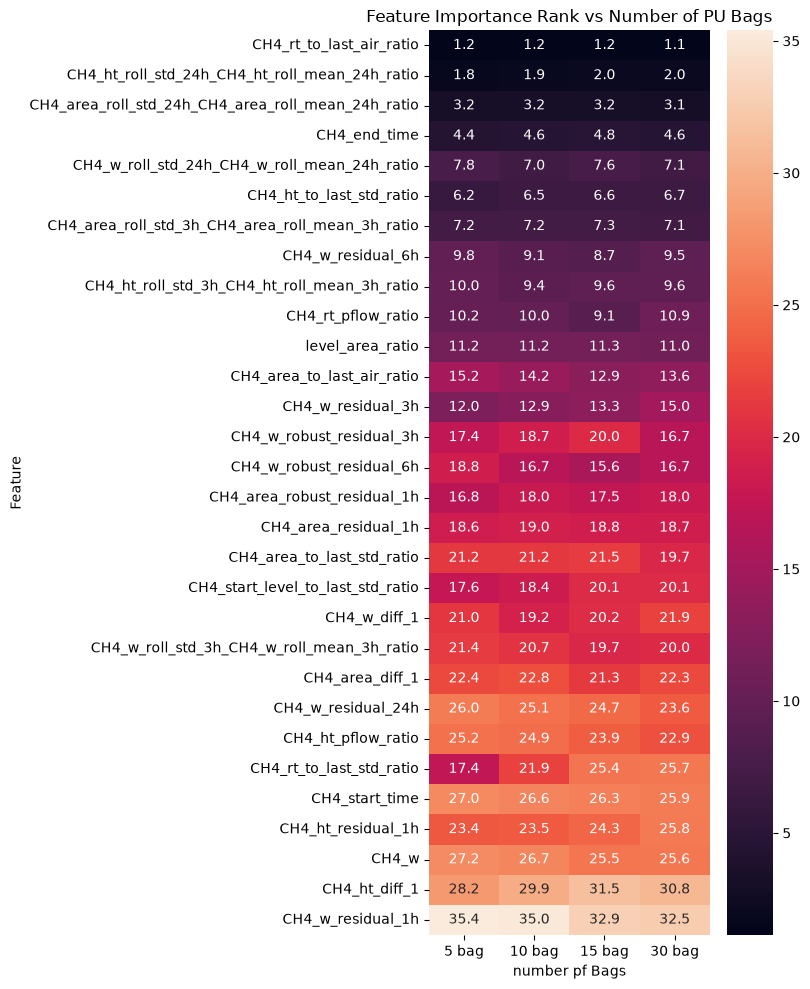

<Figure size 640x480 with 0 Axes>

In [62]:
plot_data = rank_compare.loc[top30]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".1f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance Rank vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp5_30__rank_compare.png")

#### Compare them together



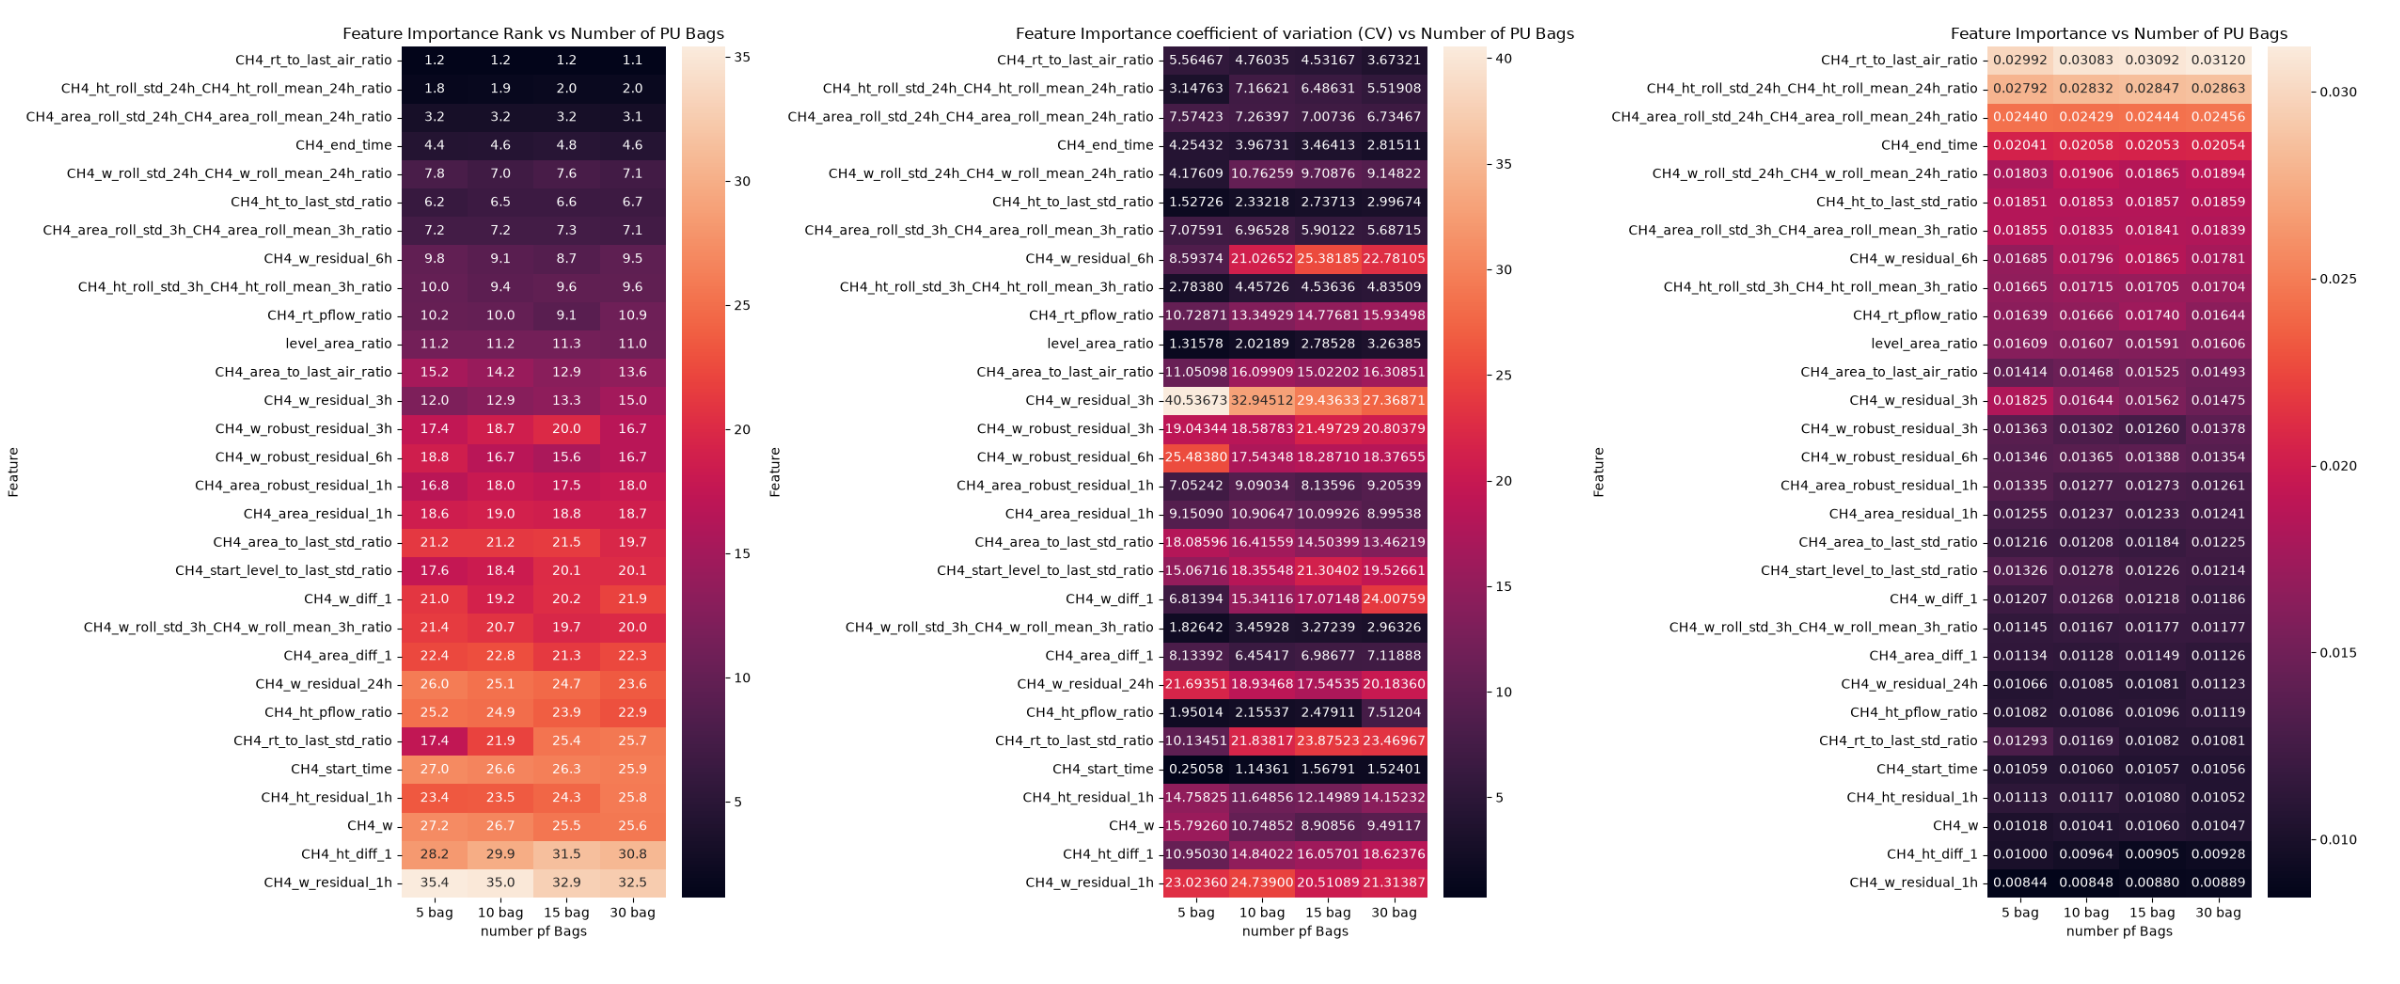

rank 的 top3 是基於mean feature importance 在30 bags
所以會看到6.7 在7.1上面

In [ ]:
# top 30' feature
top30.tolist()

['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']

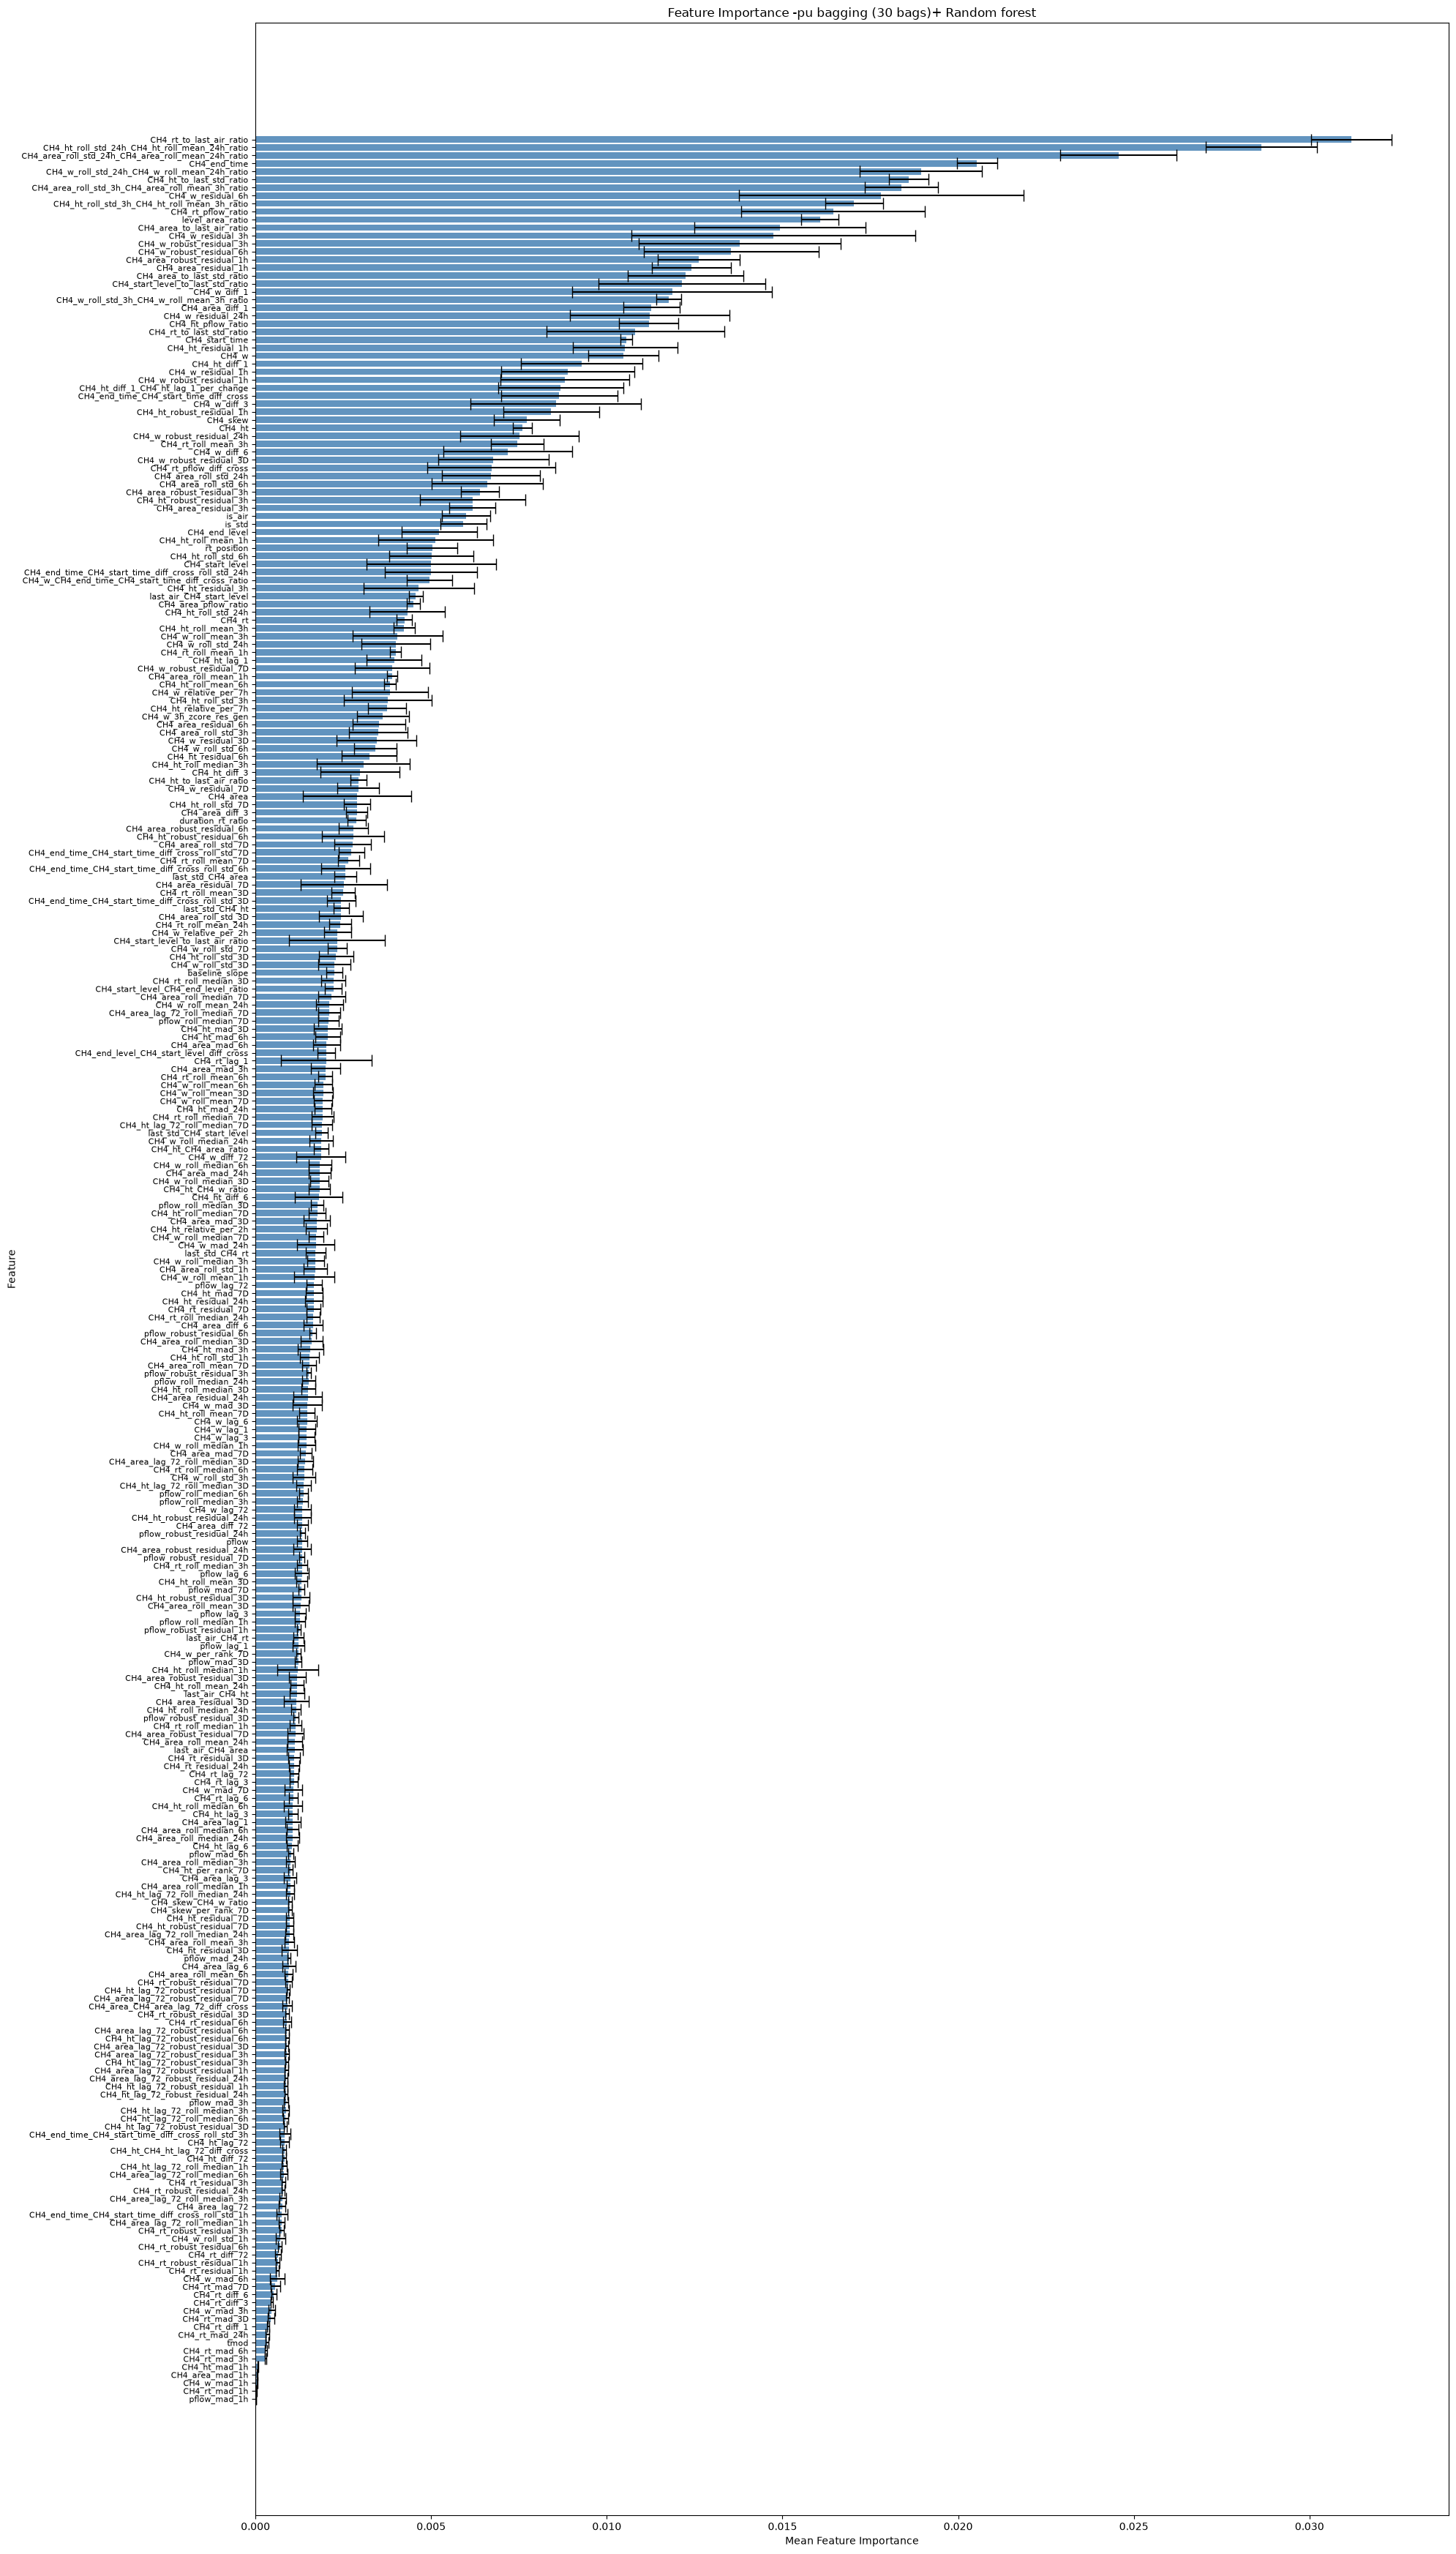

In [78]:
plot_df = (
    importance_summary_30.sort_values("importance_mean")
)
plt.figure(figsize=(20,35))

plt.barh(
    plot_df['Feature'],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.yticks(fontsize=8)
plt.title(f"Feature Importance -pu bagging (30 bags)+ Random forest")
plt.tight_layout()
plt.show()

THE PREVIOUS　Feature we use
feature_ml = ['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',]

CURRENT USE:['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']